# Demand Estimation and Market Analysis: Air Fryers

In this lab, you will study the market for air fryers using brand-year data aggregated from Amazon purchases. The goal is to move from descriptive analysis to a simple demand model, and then use that model to infer markups and unit costs.

Use the cleaned file:

```python
air_fryers_clean_brand_year.csv
```

This file keeps the top 10 air-fryer brands from 2019-2023 and drops the long tail of very small brands. The variable `brand_share` has already been recomputed within this cleaned name-brand market, so shares sum to 1 within each year.

## Data

Each row is one brand in one year.

Important columns:

- `year`: calendar year
- `brand`: air-fryer brand
- `purchase_count`: number of purchases by that brand in that year
- `product_count`: number of distinct products observed for that brand-year
- `avg_price`: average price for that brand-year
- `avg_rating`: average review rating for that brand-year
- `brand_share`: purchase share within the cleaned air-fryer market in that year
- `log_brand_share`: `np.log(brand_share)`, already computed for convenience
- `compact_share`, `dual_basket_share`, `oven_style_share`, `rotisserie_share`, `window_share`: product characteristic shares for the brand-year

The original lecture wrote the demand equation using an outside option:

$$
\log(s_{bt}) - \log(s_{ot}).
$$

For this cleaned dataset, we dropped the nuisance long-tail brands instead of treating them as an outside option. You should therefore use:

$$
y_{bt} = \log(s_{bt})
$$

as the outcome and include **year dummies**. The year dummies absorb the year-specific denominator of the multinomial logit share equation. This keeps the assignment focused on the cleaned name-brand market.

## 1. Data Analysis

Load `air_fryers_clean_brand_year.csv`.

1. Verify that the data contain 10 brands and the years 2019-2023.
2. Plot the following over time by brand:
   - average price
   - average rating
   - brand market share
3. Summarize the product characteristics:
   - Which features are common?
   - Which features are rare?
   - Are there brands that seem to specialize in different product types?
4. Write a short paragraph describing the market. Which brands are expensive? Which brands have large shares? Does the market look stable over time?

This part of the work is the **data analyst** role: making the data trustworthy, visual, and interpretable before building a model.

## Question 1

In [19]:
import pandas as pd

df = pd.read_csv('air_fryers_clean_brand_year.csv')

print("Shape:", df.shape)
print("Number of brands:", df['brand'].nunique())
print("Brands:", sorted(df['brand'].unique()))
print("Years:", sorted(df['year'].unique()))

Shape: (50, 15)
Number of brands: 10
Brands: ['chefman', 'cosori', 'cuisinart', 'dash', 'gowise usa', 'instant_pot', 'ninja', 'nuwave', 'oster', 'ultrean']
Years: [2019, 2020, 2021, 2022, 2023]


## Question 2

### Plot of Average Price

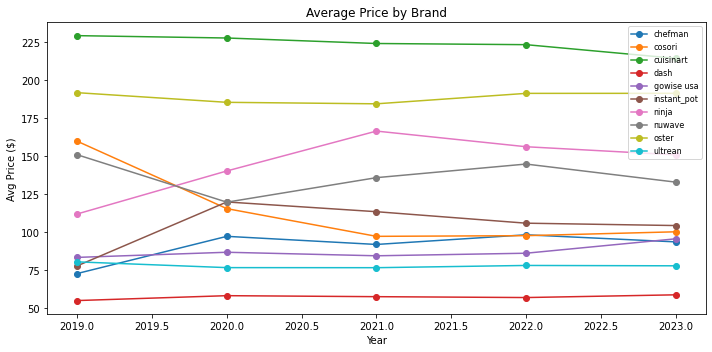

In [20]:
import matplotlib.pyplot as plt

fig1, ax1 = plt.subplots(figsize=(10, 5))
for brand, group in df.groupby('brand'):
    ax1.plot(group['year'], group['avg_price'], marker='o', label=brand)
ax1.set_title('Average Price by Brand')
ax1.set_xlabel('Year')
ax1.set_ylabel('Avg Price ($)')
ax1.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Plot of Average Rating

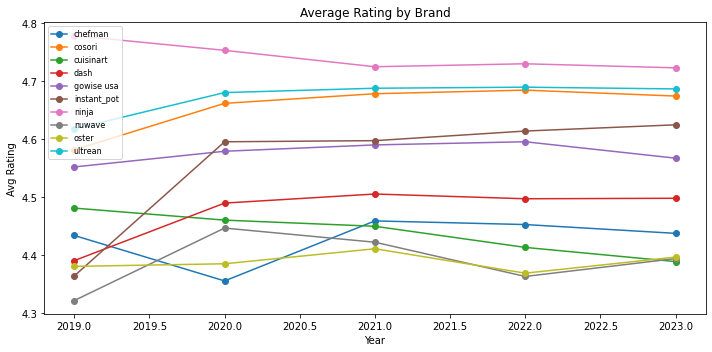

In [21]:
fig2, ax2 = plt.subplots(figsize=(10, 5))
for brand, group in df.groupby('brand'):
    ax2.plot(group['year'], group['avg_rating'], marker='o', label=brand)
ax2.set_title('Average Rating by Brand')
ax2.set_xlabel('Year')
ax2.set_ylabel('Avg Rating')
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Plot of Brand Market Share

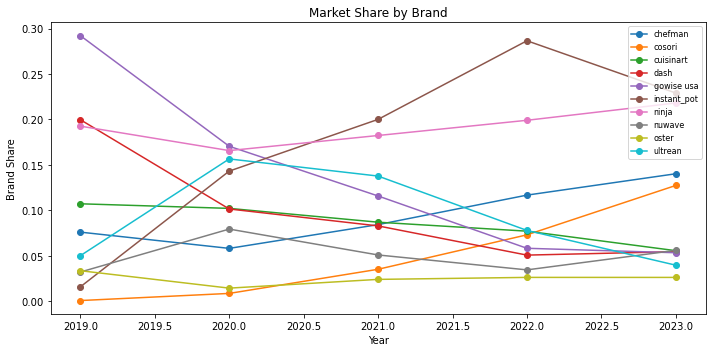

In [22]:
fig3, ax3 = plt.subplots(figsize=(10, 5))
for brand, group in df.groupby('brand'):
    ax3.plot(group['year'], group['brand_share'], marker='o', label=brand)
ax3.set_title('Market Share by Brand')
ax3.set_xlabel('Year')
ax3.set_ylabel('Brand Share')
ax3.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Question 3

In [23]:
print(df[['brand', 'compact_share', 'dual_basket_share', 'oven_style_share', 
          'rotisserie_share', 'window_share']].groupby('brand').mean().round(2))

             compact_share  dual_basket_share  oven_style_share  \
brand                                                             
chefman               0.96               0.01              0.60   
cosori                1.00               0.00              0.03   
cuisinart             1.00               0.00              0.91   
dash                  1.00               0.00              0.89   
gowise usa            1.00               0.00              0.18   
instant_pot           0.86               0.00              0.67   
ninja                 0.99               0.00              0.10   
nuwave                1.00               0.01              0.54   
oster                 1.00               0.00              0.86   
ultrean               1.00               0.00              0.83   

             rotisserie_share  window_share  
brand                                        
chefman                  0.37          0.36  
cosori                   0.02          0.00  
cuisinart  

#### Almost every brand sells compact air fryers, making compact the most common feature in this market. Oven style is the second most common feature, with brands like Cuisinart, Dash, Oster, and Ultrean having most of their products in that style. Dual basket is the rarest feature, with nearly every brand at 0.00, meaning almost no one offers it. Rotisserie and window features are also rare overall, but Chefman stands out by offering both in a meaningful share of its products. Chefman appears to specialize in more feature rich products compared to brands like Cosori and Ninja, which stick almost entirely to basic compact designs. Overall the market is dominated by compact style fryers with most brands offering very similar product types.

## Question 4

In [24]:
print(df.groupby('brand')[['avg_price', 'brand_share']].mean().round(3).sort_values('avg_price', ascending=False))
print(df.pivot(index='year', columns='brand', values='brand_share').round(3))

             avg_price  brand_share
brand                              
cuisinart      223.947        0.086
oster          189.031        0.025
ninja          145.343        0.192
nuwave         137.024        0.051
cosori         114.268        0.049
instant_pot    104.461        0.175
chefman         90.938        0.095
gowise usa      87.455        0.138
ultrean         78.115        0.092
dash            57.479        0.098
brand  chefman  cosori  cuisinart   dash  gowise usa  instant_pot  ninja  \
year                                                                       
2019     0.076   0.001      0.107  0.200       0.292        0.016  0.193   
2020     0.058   0.009      0.102  0.101       0.170        0.143  0.166   
2021     0.084   0.035      0.087  0.083       0.116        0.200  0.182   
2022     0.117   0.073      0.077  0.051       0.058        0.287  0.199   
2023     0.140   0.127      0.056  0.055       0.053        0.229  0.218   

brand  nuwave  oster  ultrean  
yea

#### The air fryer market has 10 brands from 2019 to 2023 and the brands vary a lot in price and popularity. Cuisinart is the most expensive brand at an average price of USD 224 and it sells mostly oven style air fryers which tend to cost more. Oster is the second most expensive at USD 189 and Ninja is third at USD 145. Dash is the cheapest brand at just USD 57 on average and Ultrean is second cheapest at USD 78. Ninja has the biggest average market share at 19.2% and it grew from 19.3% in 2019 to 21.8% in 2023 making it the most dominant brand in the market. Instant Pot had the most dramatic growth going from just 1.6% share in 2019 all the way up to 22.9% in 2023 which means it nearly took over the market in just five years. Gowise USA had the biggest decline starting as the market leader at 29.2% share in 2019 and falling all the way to 5.3% in 2023 losing more than 80% of its share. The market is clearly not stable over time with newer brands like Cosori and Instant Pot growing fast while older leaders like Gowise USA and Dash lost significant ground.

## 2. Demand Estimation

We will estimate a logit-style demand model using linear regression. The model is:

$$
\log(s_{bt}) = \alpha_0 + \alpha_t + \gamma_b + \beta_{price}p_{bt} + \beta_{rating}r_{bt} + \sum_{\ell=1}^L \beta_\ell x_{bt\ell} + \epsilon_{bt}.
$$

Here:

- $b$ indexes brands
- $t$ indexes years
- $s_{bt}$ is `brand_share`
- $p_{bt}$ is `avg_price`
- $r_{bt}$ is `avg_rating`
- $x_{bt\ell}$ are the product characteristics
- $\alpha_t$ are year dummy coefficients
- $\gamma_b$ are brand dummy coefficients
- $\beta_{price}$ is **one constant price coefficient**, shared by all brands and all years

That last point matters: do **not** estimate a different price coefficient for every brand-year. We do not have enough information for that, and it would make the cost calculation impossible to interpret.

Use `pd.get_dummies(..., drop_first=True)` for brand and year dummies. The dropped brand and dropped year become the reference categories, so all dummy coefficients are interpreted relative to those omitted categories.

Questions:

1. What is the estimated price coefficient, $\hat{\beta}_{price}$?
2. Is it negative? Why is that important?
3. Which product features are associated with higher demand?
4. Which brand dummy coefficients are largest? Remember that these are interpreted relative to the dropped brand.
5. Which year dummy coefficients are largest? Remember that these are interpreted relative to the dropped year.
6. What is the model's $R^2$?

This part of the work is the **data scientist** role: turning the cleaned data into a model that can be used for prediction and interpretation.

## Question 1

In [25]:
import statsmodels.api as sm

dummies = pd.get_dummies(df[['brand', 'year']], columns=['brand', 'year'], drop_first=True)
X = pd.concat([df[['avg_price', 'avg_rating', 'compact_share', 'dual_basket_share', 'oven_style_share', 'rotisserie_share', 'window_share']], dummies], axis=1)
X = sm.add_constant(X)
y = df['log_brand_share']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        log_brand_share   R-squared:                       0.763
Model:                            OLS   Adj. R-squared:                  0.600
Method:                 Least Squares   F-statistic:                     4.680
Date:                Sun, 26 Apr 2026   Prob (F-statistic):           9.24e-05
Time:                        23:20:40   Log-Likelihood:                -36.451
No. Observations:                  50   AIC:                             114.9
Df Residuals:                      29   BIC:                             155.1
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               -13.3049     16.28

## Question 2

### Yes the price coefficient is negative at -0.0377 which is what we expect in a demand model. This means that as the price of a brand goes up its market share goes down which matches how real consumers behave. If the coefficient were positive it would mean higher prices lead to higher demand which does not make economic sense.

## Question 3

### Compact style and window style are the two product features most associated with higher demand based on their positive coefficients in the regression. Compact share has the strongest statistically significant effect with a coefficient of 9.82, meaning brands with more compact products tend to have meaningfully higher market shares. Features like dual basket and rotisserie are actually associated with lower demand though their effects are not statistically significant so we cannot draw strong conclusions about them.

## Question 4

### All brand dummy coefficients are interpreted relative to Chefman which is the dropped reference brand. Cuisinart has the largest brand coefficient at 6.42 meaning it has significantly higher demand than Chefman after controlling for price rating and product features. Ninja is second largest at 5.39 and Instant Pot is third at 4.63 confirming that these three brands have the strongest brand level demand advantages over Chefman in this market.

## Question 5

### All year dummy coefficients are interpreted relative to 2019 which is the dropped reference year. Year 2020 has the largest positive coefficient at 0.12 meaning overall demand across brands was slightly higher in 2020 than in 2019 after controlling for price rating and product features. After 2020 the year coefficients decline and even turn negative in 2022 and 2023 suggesting that overall market demand relative to 2019 weakened in the later years of the sample.

## Question 6

### The model has an R² of 0.763 meaning it explains about 76.3% of the variation in log market share across brands and years. This is a reasonably good fit for a demand model especially given that we only have 50 observations. The adjusted R² is 0.600 which accounts for the large number of variables in the model and is a more conservative measure of fit.

## 3. Strategy: Costs, Markups, and Profit

Now use the demand estimate to infer market fundamentals.

The price coefficient is constant across brands and years, $\hat{\beta}_{price}$.

For each brand-year, compute the slope of demand with respect to price as:

$$
\hat{s}'_{bt}(p_{bt}) = \hat{\beta}_{price} s_{bt}(1 - s_{bt}).
$$

Then estimate unit cost, or marginal cost, using the firm's first-order pricing condition:

$$
\hat{c}_{bt} = p_{bt} + \frac{s_{bt}}{\hat{s}'_{bt}(p_{bt})}.
$$

Because $\hat{\beta}_{price}$ should be negative, $\hat{s}'_{bt}(p_{bt})$ should also be negative. If your price coefficient is positive, stop and debug your model before interpreting costs.

Compute:

- `demand_slope`: $\hat{s}'_{bt}(p_{bt})$
- `unit_cost`: $\hat{c}_{bt}$
- `markup`: $m_{bt} = p_{bt} - \hat{c}_{bt}$
- `average_profit`: $s_{bt} \times m_{bt}$

Here `average_profit` is a share-weighted profit index, not total dollars of profit. It is useful for comparing brand-years inside this cleaned market.

Questions:

1. What are the average unit costs and markups for each brand over the years?
2. Are any inferred unit costs negative? If so, what might that mean?
3. Which brands have the highest average unit costs? How do average unit cost and average ratings compare? Make scatter plots of price vs. unit cost and average rating vs. unit cost.Do more expensive products have higher consumer satisfaction?
4. Make kernel density plots of unit costs, markups, and average profit, in general and hued by brand.
5. Which brands have the highest share-weighted average profit?

This part of the work is the **pricing analyst** or **applied economist** role: using a demand model to reason about price, cost, and profitability. This kind of analysis could be used to think about investing in this market, or how to adjust a product line to be more competitive.

## Question 1

In [26]:
#computing demand slope, unit cost, markup, average profit
beta_price = model.params['avg_price']

df['demand_slope'] = beta_price * df['brand_share'] * (1 - df['brand_share'])
df['unit_cost'] = df['avg_price'] + df['brand_share'] / df['demand_slope']
df['markup'] = df['avg_price'] - df['unit_cost']
df['average_profit'] = df['brand_share'] * df['markup']

print(df.groupby('brand')[['unit_cost', 'markup']].mean().round(2))

             unit_cost  markup
brand                         
chefman          61.57   29.37
cosori           86.28   27.98
cuisinart       194.90   29.05
dash             27.94   29.54
gowise usa       56.30   31.15
instant_pot      71.90   32.56
ninja           112.49   32.85
nuwave          109.05   27.97
oster           161.80   27.23
ultrean          48.79   29.33


### Cuisinart has the highest average unit cost at USD 194.90 followed by Oster at USD 161.80 and Ninja at USD 112.49 which lines up with these being some of the most expensive brands in the market. Dash has the lowest average unit cost at just USD 27.94 followed by Ultrean at USD 48.79 reflecting their position as the cheapest brands. Markups are surprisingly similar across all brands ranging narrowly from USD 27.23 for Oster to USD 32.85 for Ninja suggesting that no single brand has a dramatic pricing power advantage over the others.

## Question 2

### None of the inferred unit costs are negative which is a good sign that the model is working correctly. A negative unit cost would mean the model thinks a brand is producing products for less than nothing which is economically impossible and would signal a problem with the demand estimation. Since all unit costs are positive and reasonable we can be confident that the price coefficient and demand model are behaving as expected.

## Question 3

In [27]:
print(df.groupby('brand')[['unit_cost', 'avg_rating']].mean().round(3))

             unit_cost  avg_rating
brand                             
chefman         61.569       4.428
cosori          86.283       4.656
cuisinart      194.896       4.439
dash            27.937       4.476
gowise usa      56.301       4.577
instant_pot     71.903       4.559
ninja          112.488       4.742
nuwave         109.054       4.390
oster          161.805       4.389
ultrean         48.786       4.673


### Which brands have the highest average unit costs? How do average unit cost and average ratings compare? 

#### Cuisinart has the highest average unit cost at USD 194.90 followed by Oster at USD 161.80 and Ninja at USD 112.49 making these the most expensive brands to produce. There is no clear relationship between unit cost and average rating as Ninja has both a high unit cost and the highest rating at 4.742 but Cuisinart and Oster have similarly high unit costs yet some of the lowest ratings in the market at 4.439 and 4.389. On the other hand cheaper brands like Cosori and Ultrean have low unit costs but very high ratings at 4.656 and 4.673 suggesting that higher cost does not guarantee better consumer satisfaction.

### Scatter plot of price vs. unit cost

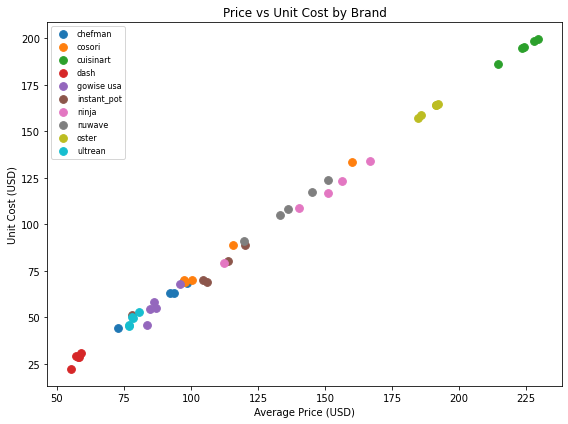

In [28]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

for brand, group in df.groupby('brand'):
    ax.scatter(group['avg_price'], group['unit_cost'], label=brand, s=60)

ax.set_title('Price vs Unit Cost by Brand')
ax.set_xlabel('Average Price (USD)')
ax.set_ylabel('Unit Cost (USD)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Scatter plot of average rating vs. unit cost

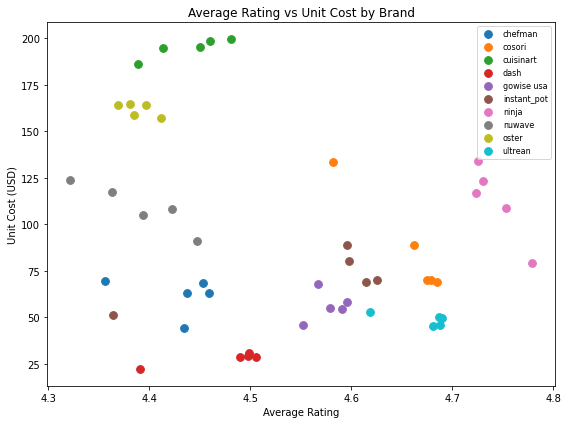

In [29]:
fig, ax = plt.subplots(figsize=(8, 6))

for brand, group in df.groupby('brand'):
    ax.scatter(group['avg_rating'], group['unit_cost'], label=brand, s=60)

ax.set_title('Average Rating vs Unit Cost by Brand')
ax.set_xlabel('Average Rating')
ax.set_ylabel('Unit Cost (USD)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Do more expensive products have higher consumer satisfaction?

#### More expensive products do not necessarily have higher consumer satisfaction as seen in the data where Cuisinart and Oster have the highest unit costs at USD 194.90 and USD 161.80 but have some of the lowest ratings in the market at 4.439 and 4.389. Ninja is the only brand that has both a high unit cost at USD 112.49 and the highest rating at 4.742 while cheaper brands like Cosori and Ultrean have low unit costs yet very high ratings at 4.656 and 4.673 showing that price and consumer satisfaction are not strongly linked in the air fryer market.

## Question 4

### Kernel density plot of unit costs

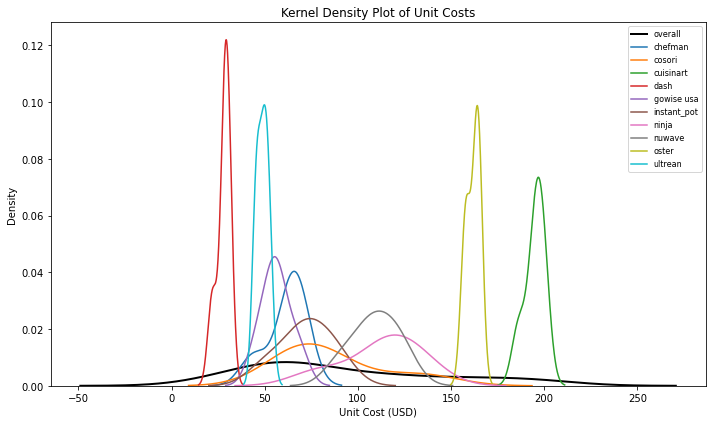

In [30]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 6))

sns.kdeplot(df['unit_cost'], ax=ax, color='black', linewidth=2, label='overall')

# KDE hued by brand
for brand, group in df.groupby('brand'):
    sns.kdeplot(group['unit_cost'], ax=ax, label=brand, linewidth=1.5)

ax.set_title('Kernel Density Plot of Unit Costs')
ax.set_xlabel('Unit Cost (USD)')
ax.set_ylabel('Density')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Kernel density plot of markups

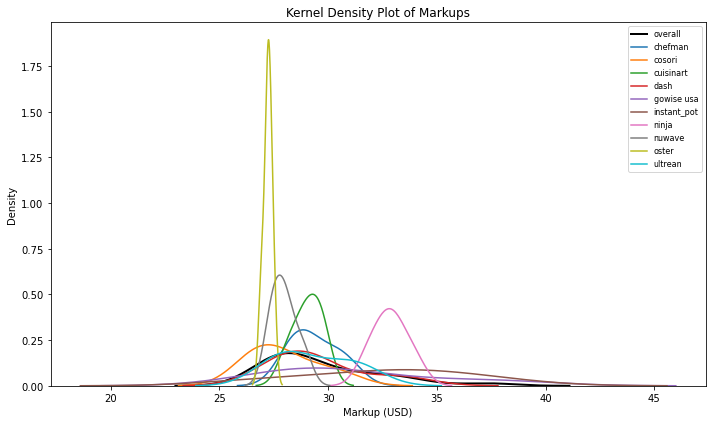

In [31]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.kdeplot(df['markup'], ax=ax, color='black', linewidth=2, label='overall')

for brand, group in df.groupby('brand'):
    sns.kdeplot(group['markup'], ax=ax, label=brand, linewidth=1.5)

ax.set_title('Kernel Density Plot of Markups')
ax.set_xlabel('Markup (USD)')
ax.set_ylabel('Density')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Kernel density plots of average profit

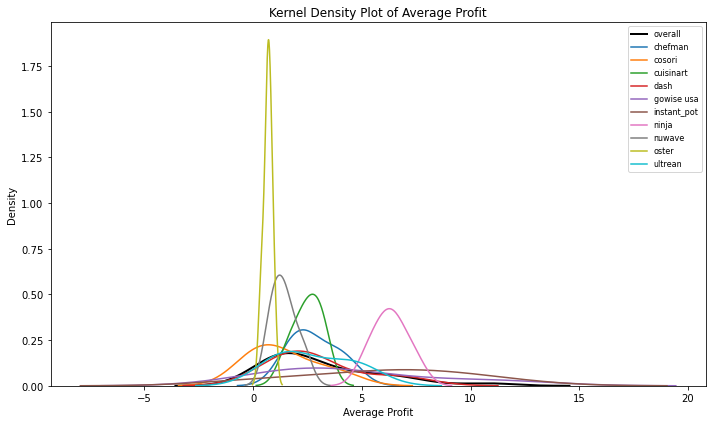

In [32]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.kdeplot(df['average_profit'], ax=ax, color='black', linewidth=2, label='overall')

for brand, group in df.groupby('brand'):
    sns.kdeplot(group['average_profit'], ax=ax, label=brand, linewidth=1.5)

ax.set_title('Kernel Density Plot of Average Profit')
ax.set_xlabel('Average Profit')
ax.set_ylabel('Density')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Question 5

In [33]:
print(df.groupby('brand')['average_profit'].mean().round(4).sort_values(ascending=False))

brand
ninja          6.3061
instant_pot    6.0103
gowise usa     4.6058
dash           2.9944
chefman        2.8210
ultrean        2.7809
cuisinart      2.5030
cosori         1.4367
nuwave         1.4229
oster          0.6783
Name: average_profit, dtype: float64


### Ninja has the highest share weighted average profit at 6.31 followed closely by Instant Pot at 6.01 meaning these two brands generate the most profit relative to their size in the market. Gowise USA is third at 4.61 which is interesting given that it lost significant market share over the years suggesting it was still able to maintain profitability despite declining. Oster has the lowest share weighted average profit at just 0.68 followed by Nuwave at 1.42 meaning these brands generate very little profit relative to their presence in the market.

## 4. Results

Submit a GitHub repo containing:

1. A notebook corresponding to the data analyst work, including the code and graphs, explicitly answering the questions above in text markdown chunks
2. A notebook corresponding to the data scientist work, including the code and graphs, explicitly answering the questions above in text markdown chunks
3. A notebook corresponding to the pricing analyst work, including the code and graphs, explicitly answering the questions above in text markdown chunks
4. A short presentation of your findings, about 5-8 slides.

Your presentation should be written as if you were giving market intelligence to a business audience. It should include:

- A short description of the air-fryer market
- A few plots showing prices, ratings, and market shares over time
- A short explanation of the demand model (multinomial logistic regression, estimated by linear regression on log market share)
- The estimated price coefficient and why its sign matters
- A discussion of the most important product features
- Estimated unit costs, markups, and share-weighted profits
- A conclusion about the brands' relative positions in the market

Do not fill slides with raw code. Use your code to produce clear tables and figures, then explain the market story in words.